In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from pandas.plotting import parallel_coordinates, scatter_matrix
from sklearn.preprocessing import StandardScaler

# Load the new synthetic diamonds dataset
np.random.seed(42)
n_rows = 5000
diamonds = pd.DataFrame({
    'carat': np.round(np.random.uniform(0.1, 5.0, n_rows), 2),
    'depth': np.round(np.random.uniform(55, 70, n_rows), 2),
    'table': np.round(np.random.uniform(50, 70, n_rows), 2),
    'price': np.random.randint(300, 20000, n_rows),
    'cut': np.random.choice(['Fair', 'Good', 'Very Good', 'Premium', 'Ideal'], n_rows)
})
diamonds.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB
None
   carat      cut color clarity  depth  table  price     x     y     z
0   0.23    Ideal     E     SI2   61.5   55.0    326  3.95  3.98  2.43
1   0.21  Premium     E     SI1   59.8   61.0    326  3.89  3.84  2.31
2   0.23     Good     E     VS1   56.9   65.0    327  4.05  4.07  2.31
3   0.29  Premium     I     VS2   62.4   58.0    334  4.20  4.23  2.63
4   0.31     

#  Parallel Coordinates Plot


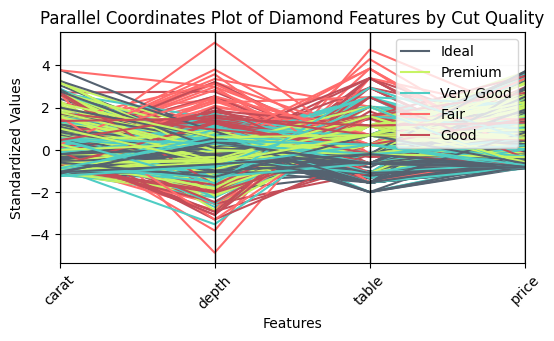

In [14]:
# Select numeric features and one categorical feature
numeric_features = ['carat', 'depth', 'table', 'price']
categorical_feature = 'cut'

# Create a sample for clearer visualization (parallel coord plots can get crowded)
sample_df = diamonds.sample(1000)

# Standardize the numeric features for better visualization
scaler = StandardScaler()
sample_std = sample_df.copy()
sample_std[numeric_features] = scaler.fit_transform(sample_std[numeric_features])

# Create parallel coordinates plot
plt.figure(figsize=(6, 3))
parallel_coordinates(sample_std, 'cut', cols=numeric_features, color=('#556270', '#C7F464', '#4ECDC4', '#FF6B6B', '#C44D58'))
plt.title('Parallel Coordinates Plot of Diamond Features by Cut Quality')
plt.xlabel('Features')
plt.ylabel('Standardized Values')
plt.xticks(rotation=45)
plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.show()

# Scatter Coordinates Plot

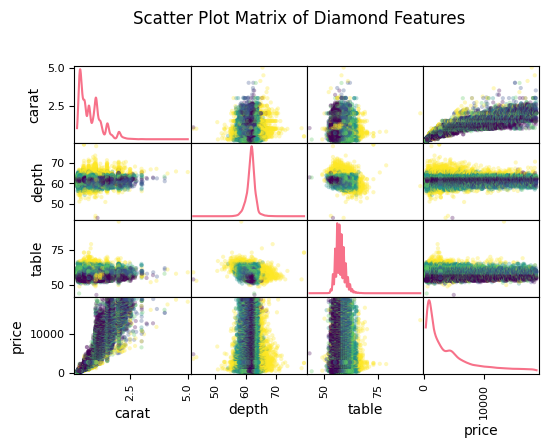

In [16]:
# Create scatter matrix
scatter_matrix(diamonds[numeric_features], figsize=(6, 4), diagonal='kde', 
               c=pd.factorize(diamonds[categorical_feature])[0], alpha=0.3)
plt.suptitle('Scatter Plot Matrix of Diamond Features', y=1.02)
plt.show()

# Seaborn Pairplot

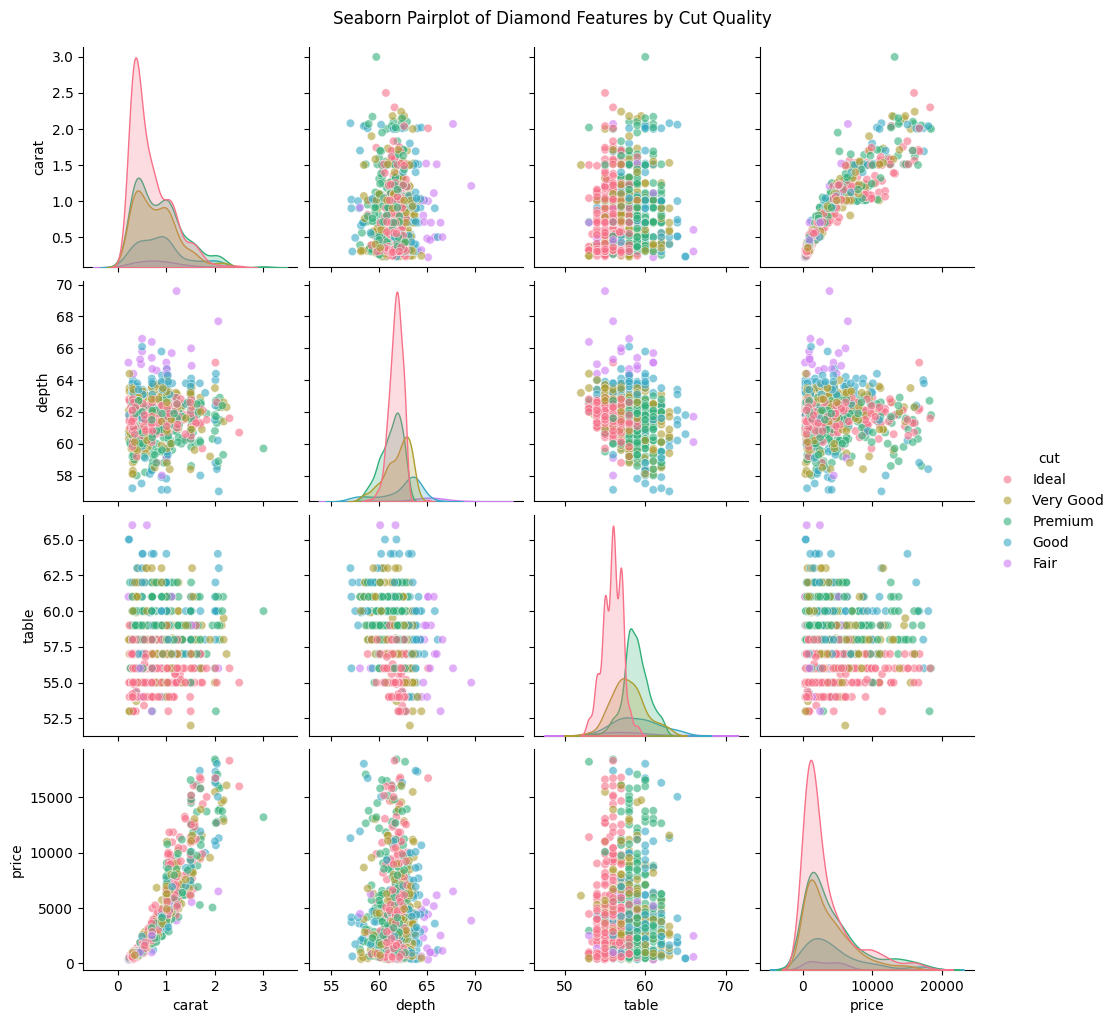

In [10]:
# Create pairplot with a smaller sample for better performance
sample_for_pairplot = diamonds.sample(1000)
sns.pairplot(sample_for_pairplot, vars=numeric_features, hue='cut', 
             palette='husl', plot_kws={'alpha': 0.6})
plt.suptitle('Seaborn Pairplot of Diamond Features by Cut Quality', y=1.02)
plt.show()

# PCA Projection

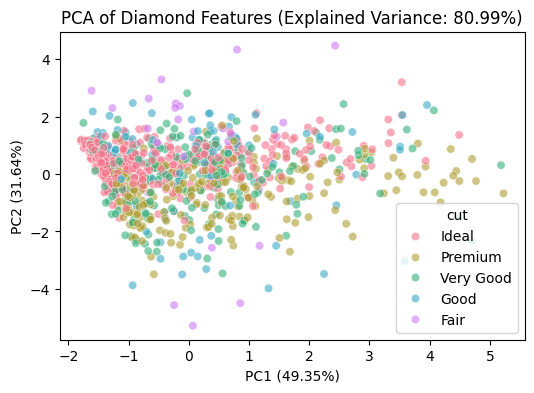

In [17]:
# Prepare data for PCA
X = diamonds[numeric_features]
X_std = StandardScaler().fit_transform(X)

# Perform PCA
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_std)

# Create DataFrame for plotting
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
pca_df['cut'] = diamonds['cut']

# Plot
plt.figure(figsize=(6, 4))
sns.scatterplot(x='PC1', y='PC2', hue='cut', data=pca_df.sample(1000), 
                palette='husl', alpha=0.6)
plt.title(f'PCA of Diamond Features (Explained Variance: {pca.explained_variance_ratio_.sum()*100:.2f}%)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
plt.show()

# t-SNE Embedding


In [ ]:
# Perform t-SNE - we'll use a smaller sample for performance
sample_for_tsne = diamonds.sample(1000)
X_sample = sample_for_tsne[numeric_features]
X_sample_std = StandardScaler().fit_transform(X_sample)

# Run t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_results = tsne.fit_transform(X_sample_std)

# Create DataFrame for plotting
tsne_df = pd.DataFrame(data=tsne_results, columns=['TSNE1', 'TSNE2'])
tsne_df['cut'] = sample_for_tsne['cut']

# Plot
plt.figure(figsize=(8, 5))
sns.scatterplot(x='TSNE1', y='TSNE2', hue='cut', data=tsne_df, 
                palette='husl', alpha=0.6)
plt.title('t-SNE Visualization of Diamond Features')
plt.show()